In [1]:
import sys
import healpy as hp
import numpy as np
sys.path.insert(0,"../..")
import select_and_orient as sao
import glob
import stacking_functions as sf
from pixell import enmap, enplot, reproject, utils
import matplotlib.pyplot as plt
def eshow(x,**kwargs): enplot.show(enplot.plot(x,**kwargs))
%load_ext autoreload
%autoreload 2

In [2]:
orient_catalog = "/mnt/raid-cita/mlokken/data/desi/LRG_clustering.dat.fits"
stack_catalog  = "/mnt/raid-cita/mlokken/data/desi/LRG_clustering_Y1_zred_desi_complete_thresh0.7_excl0.4deg_ACTmasked.fits"
ra_oo, dec_oo, z_oo, w_oo = sao.get_radecz(orient_catalog, return_weight=True)
ra_so, dec_so, z_so, w_so = sao.get_radecz(stack_catalog, return_weight=True)
ra_rand = []
dec_rand = []
z_rand = []
w_rand = []
randoms = glob.glob("/mnt/raid-cita/mlokken/data/desi/randoms/LRG_*_clustering.ran.fits")
for ranfile in randoms:
    ra_rand_i, dec_rand_i, z_rand_i, w_rand_i = sao.get_radecz(ranfile, return_weight=True)
    ra_rand.extend(ra_rand_i)
    dec_rand.extend(dec_rand_i)
    z_rand.extend(z_rand_i)
    w_rand.extend(w_rand_i)


DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.


In [3]:
ra_rand = np.array(ra_rand)
dec_rand = np.array(dec_rand)
z_rand = np.array(z_rand)
w_rand = np.array(w_rand)


In [4]:
zmin = 0.6
zmax = 0.61
inz_oo = (z_oo<zmax) & (z_oo>zmin)
inz_rand = (z_rand<zmax) & (z_rand>zmin)

In [5]:
ra_rand_inz = ra_rand[inz_rand]
dec_rand_inz = dec_rand[inz_rand]
w_rand_inz = w_rand[inz_rand]
ra_oo_inz = ra_oo[inz_oo]
dec_oo_inz = dec_oo[inz_oo]
w_oo_inz = w_oo[inz_oo]
del ra_rand, dec_rand, z_rand, w_rand, z_oo, w_oo, ra_oo, dec_oo

sum data 44505.59191930044 sum rand 3179070.525677029
alpha is 0.013999561054035558
Min of randoms within threhsold is 0.20212138655441958
Mean smoothed diff -3.739262142149621e-06 Mean smoothed rand 3.6900582454343605 Mean smoothed data 0.05165545643776352 ratio data to rand with alpha 0.9999276167177696
Mean data: 0.05175435922699218
Mean rand: 3.6968300669453678
Mean of delta map is 7.222569702189828e-05


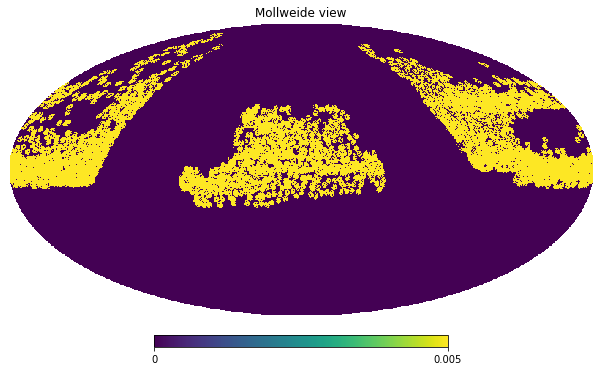

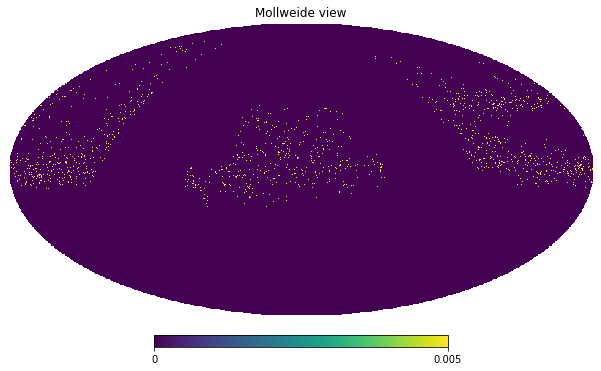

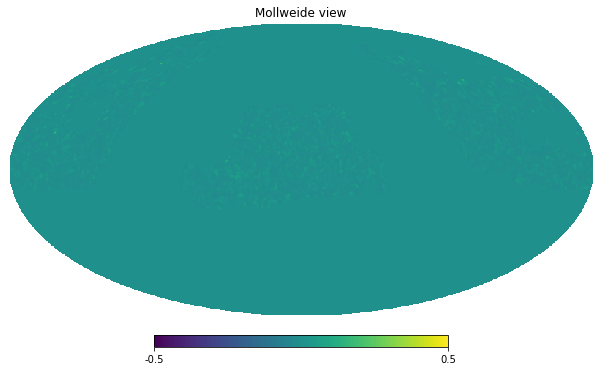

In [6]:
nside = 512
deltag = sao.delta_g(nside, ra_oo_inz, dec_oo_inz, ra_rand=ra_rand_inz, dec_rand=dec_rand_inz, catalog_weights=w_oo_inz, randoms_weights=w_rand_inz, alpha=1, smth=60, beam='gaussian') 

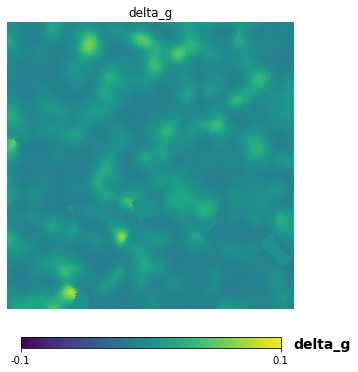

In [7]:
ra_range = [0,20]
dec_range = [-10,10]
deltag_cartmap = hp.cartview(deltag, title="delta_g", unit="delta_g", min=-.1, max=.1, lonra=ra_range, latra=dec_range, return_projected_map=True)

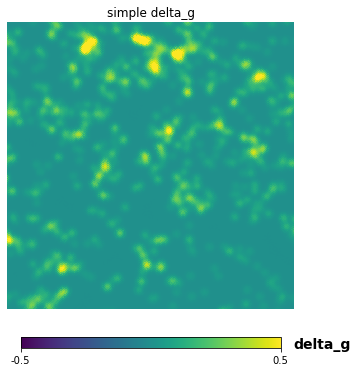

In [8]:
# compare to a simple map
deltamap_2 = np.zeros(hp.nside2npix(nside))
pix = hp.ang2pix(nside, ra_oo_inz, dec_oo_inz, lonlat=True)
np.add.at(deltamap_2, pix, w_oo_inz)
smth_deltamap_2 = hp.smoothing(deltamap_2, fwhm=np.radians(30/60))
hp.cartview(smth_deltamap_2, title="simple delta_g", unit="delta_g", min=-.5, max=.5, lonra=[0,20], latra=[-10,10])

In [41]:
# convert delta_g to enmap
# set up an empty enmap geometry
shape,wcs = enmap.fullsky_geometry(res=5 * utils.arcmin,proj='car')
deltag_enmap = reproject.healpix2map(deltag, shape=shape, wcs=wcs)

In [91]:
npix  = hp.nside2npix(nside)
th, ph = hp.pixelfunc.pix2ang(nside, np.arange(npix))
cotth = np.cos(th)/np.sin(th)

In [92]:
in_so_bin = (z_so<0.608)&(z_so>0.602)
z_so_bin = z_so[in_so_bin]
ra_so_bin = ra_so[in_so_bin]
dec_so_bin = dec_so[in_so_bin]
w_so_bin  = w_so[in_so_bin]

NameError: name 'z_so' is not defined

In [ ]:
del z_so, ra_so, dec_so, w_so

In [93]:
alpha, xpol, ypol, ca, sa, cut = sao.measure_orientation(ra_so_bin, dec_so_bin, deltag, cotth, e_min=0.3, e_max=None, nu_min=2, mode='density', return_xy_pol=True)

(6259, 2, 2)
Computed rms of the field: 0.0066
[-40.26410468 216.51146615]
[-118.49250736  445.71264668]
[-28.42162511 232.61717876]
[-113.97265162  491.85576775]
[ 20.56147106 614.29260854]
[ 13.11395597 585.65111051]
[-123.64795232  449.99008541]
[ 12.01612314 240.63034985]
[ 30.45708797 432.4610188 ]
[  3.54380349 345.70322181]
[  3.54380349 345.70322181]
[113.98436215 489.7312196 ]
[-82.3381732  389.42610993]
[ 10.16125817 568.43567287]
[112.77942816 577.48051144]
[-46.87998643 246.27119888]
[-46.87998643 246.27119888]
[-43.51609615 165.95389735]
[-25.8055666  266.23224643]
[-43.94264267 326.20251953]
[-16.75288955 500.37440209]
[ 25.73164971 486.33024139]
[-78.73813095 457.93596015]
[-62.93705698 272.82634996]
[-24.08513385 318.47948078]
[-235.74520067  309.6113645 ]
[-35.8865716  216.37526215]
[-70.58339521 102.66345301]
[ 66.618979   279.96115341]
[ 32.88639938 351.14212043]
[ 32.88639938 351.14212043]
[ 35.05436322 303.70433612]
[-110.76712567  329.44462266]
[-196.67563257  228

In [94]:
from astropy import wcs
w = wcs.WCS(naxis=2)

height = float(deltag_cartmap.shape[0])
length = float(deltag_cartmap.shape[1])
w = wcs.WCS(naxis=2)
cdeltaX, crvalX = (ra_range[0]-ra_range[1])/length, (ra_range[0]+ra_range[1])/2.
cdeltaY, crvalY = (dec_range[1]-dec_range[0])/height, (dec_range[0]+dec_range[1])/2.


w.wcs.crpix = length/2., height/2.
print(w.wcs.crpix)
w.wcs.crval = [crvalX,crvalY]
print(w.wcs.crval)
w.wcs.cdelt = np.array([cdeltaX,cdeltaY])
print(w.wcs.cdelt)
w.wcs.ctype = ["RA", "DEC"]

[400. 400.]
[10.  0.]
[-0.025  0.025]


In [95]:
def get_vector_components(rot_angle):
    # make it work for a single angle or an array of angles
    rot_angle = np.atleast_1d(rot_angle)
    U_arr = np.zeros(len(rot_angle))
    V_arr = np.zeros(len(rot_angle))
    m = 0
    for r in rot_angle:

        if (r <= np.pi/2.) or (r > 3*np.pi/2.):
            U = 1/np.sqrt(1+np.tan(r)**2)
        else:
            U = -1/np.sqrt(1+np.tan(r)**2)
        V = U * np.tan(r)
        U_arr[m] = U
        V_arr[m] = V
        m += 1
    return U_arr, V_arr

In [96]:
ra_cut = ra_so_bin[cut]
dec_cut = dec_so_bin[cut]
sel_area  = (ra_cut>ra_range[0])&(ra_cut<ra_range[1])&(dec_cut>dec_range[0])&(dec_cut<dec_range[1])
selection = sel_area
Xpix,Ypix = w.all_world2pix(ra_cut[selection], dec_cut[selection], 0)
U_arr, V_arr = get_vector_components(alpha[selection])

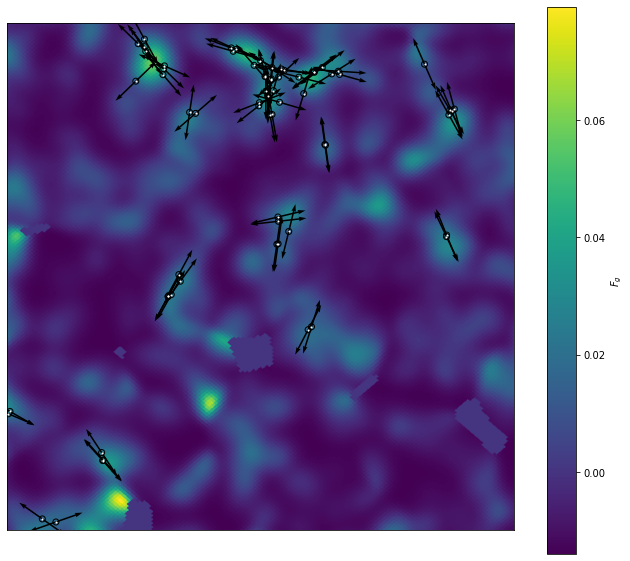

In [97]:
# Make the figure

fig = plt.figure(figsize=(20,20))

nrows = 2
ax1 = plt.subplot(1, 2, 1, projection=w)
# ax2 = plt.subplot(1, 2, 2, projection=w)

ax1.set_xticks([])
ax1.set_xticklabels([])

dmap = ax1.imshow(deltag_cartmap)


# plt.colorbar(sc1, cax=ax1)

ax1.set_xlabel("RA")
ax1.set_ylabel("Dec")


# Make the figure


# ax1.contour(od_map_flat, colors='royalblue', zorder=1)
indices = np.arange(len(Xpix))
indices = np.delete(indices,[1,3,8,10,11,12,13,14])
sc1 = ax1.scatter(Xpix[indices],Ypix[indices], linewidths=1,  edgecolors='k', facecolor='None', zorder=1)

ax1.quiver(Xpix[indices],Ypix[indices], -U_arr[indices], V_arr[indices], width=0.003, color = 'k',  zorder=2)
qv = ax1.quiver(Xpix[indices],Ypix[indices], U_arr[indices], -V_arr[indices], width=0.003, color = 'k',  zorder=3)
ax1.scatter(Xpix[indices],Ypix[indices], linewidths=1, s=1, c='w', zorder=4)

lon = ax1.coords[0]
lat = ax1.coords[1]


# produce a legend with a cross section of sizes from the scatter
handles, labels = sc1.legend_elements(prop="sizes", alpha=0.6)
label_flt = [(float(l.split('{')[1][:-2])/10)**(1/3) for l in labels]
where_max = np.where(np.asarray(label_flt)==max(label_flt))[0][0]
where_min = np.where(np.asarray(label_flt)==min(label_flt))[0][0]
labels = np.asarray(["%.1f"%flt for flt in label_flt])
handles = np.asarray(handles)

fd = {"size":8}
for handle in handles:
    handle.set(fillstyle="none", color='k', alpha=1)
# legend1 = ax1.legend(handles[[where_min,where_max]], labels[[where_min,where_max]], loc="upper left", ncol=2, title=r"$\nu$ scale", prop={'size': 10})
# plt.setp(legend1.get_title(),fontsize=9)





lon.set_ticks_visible(False)
lon.set_ticklabel_visible(False)
lat.set_ticks_visible(False)
lat.set_ticklabel_visible(False)

cbar_ax = fig.add_axes([0.5, 0.31, 0.02, 0.38])
cb = plt.colorbar(dmap, ax=ax1, cax=cbar_ax)
cb.set_label("$F_g$")




In [98]:
Chunk = sf.Chunk(ra_so_bin[cut], dec_so_bin[cut], alpha, x_asym=xpol, y_asym=ypol)


In [99]:
geom = sf.StackGeometry(2, .1)

shape is (41, 41)


In [106]:
stack = sf.stackChunk(Chunk, geom, deltag_enmap, orient='asym_y')

rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot matrix.
rot 

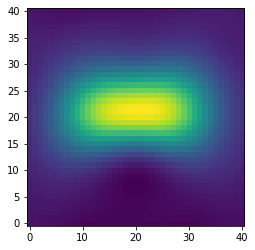

In [107]:
plt.imshow(stack, origin='lower')

In [44]:
# now test with the diag-lines map
diaglines = enmap.read_map("/mnt/raid-cita/mlokken/data/many_diagonal_lines_single_direction_map.fits")

# diaglines = enmap.read_map("/mnt/raid-cita/mlokken/data/many_diagonal_lines_multi_direction_map.fits")

In [62]:
# diaglines_hpx = hp.read_map("/mnt/raid-cita/mlokken/data/many_diagonal_lines_multi_direction_map_hpx.fits")
diaglines_hpx = hp.read_map("/mnt/raid-cita/mlokken/data/many_diagonal_lines_single_direction_map_hpx.fits")
diaglines_hpx_smth = hp.smoothing(diaglines_hpx, fwhm=np.radians(30/60))
# modify diaglines_hpx to have zero mean
diaglines_hpx_smth -= np.mean(diaglines_hpx_smth)
npix  = hp.nside2npix(hp.get_nside(diaglines_hpx_smth))
th, ph = hp.pixelfunc.pix2ang(nside, np.arange(npix))
dl_cotth = np.cos(th)/np.sin(th)

/cita/modules/python/3.10.2/lib/python3.10/site-packages/healpy/pixelfunc.py:529: RuntimeWarning: divide by zero encountered in _pix2ang_ring
  theta, phi = pixlib._pix2ang_ring(nside, ipix)
/cita/modules/python/3.10.2/lib/python3.10/site-packages/healpy/pixelfunc.py:529: RuntimeWarning: invalid value encountered in _pix2ang_ring
  theta, phi = pixlib._pix2ang_ring(nside, ipix)


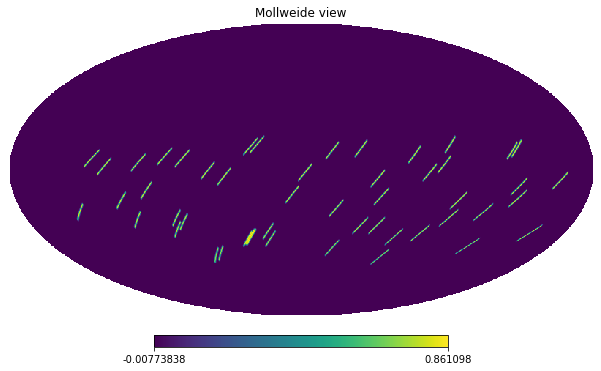

In [63]:
hp.mollview(diaglines_hpx_smth)

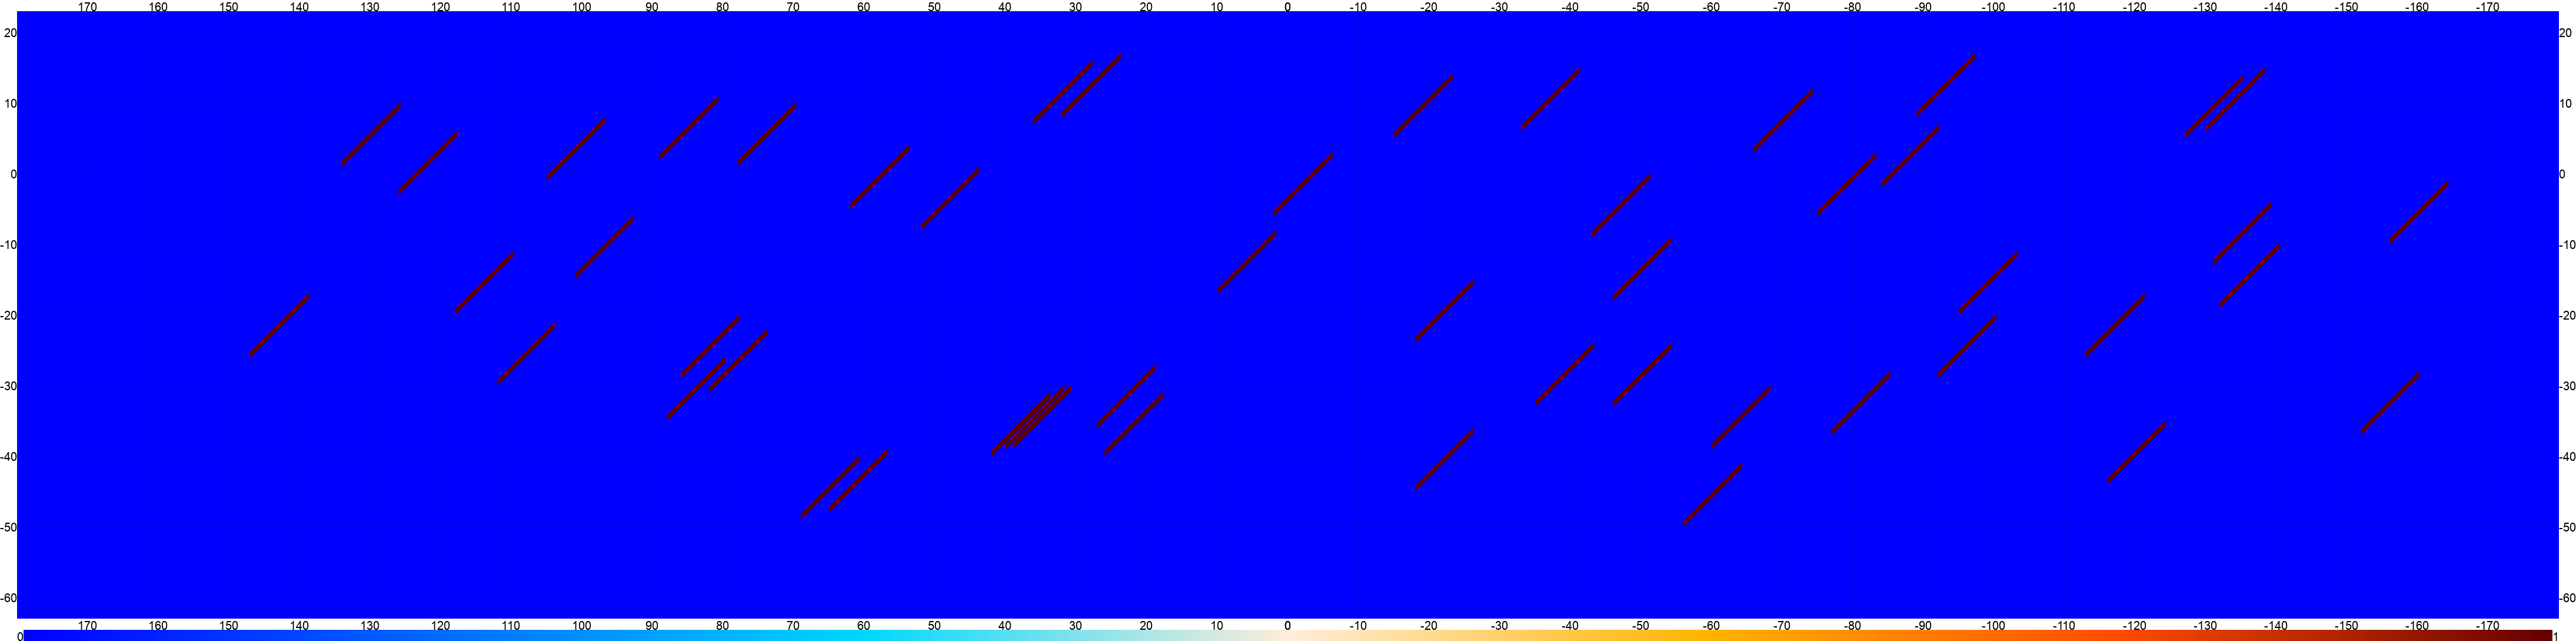

In [47]:
eshow(diaglines, colorbar=True, ticks=10)

In [48]:
radec = np.loadtxt("../../testing/testing_data/ra_dec_list_manydiag.txt")
ra = radec[:,0]
dec = radec[:,1]

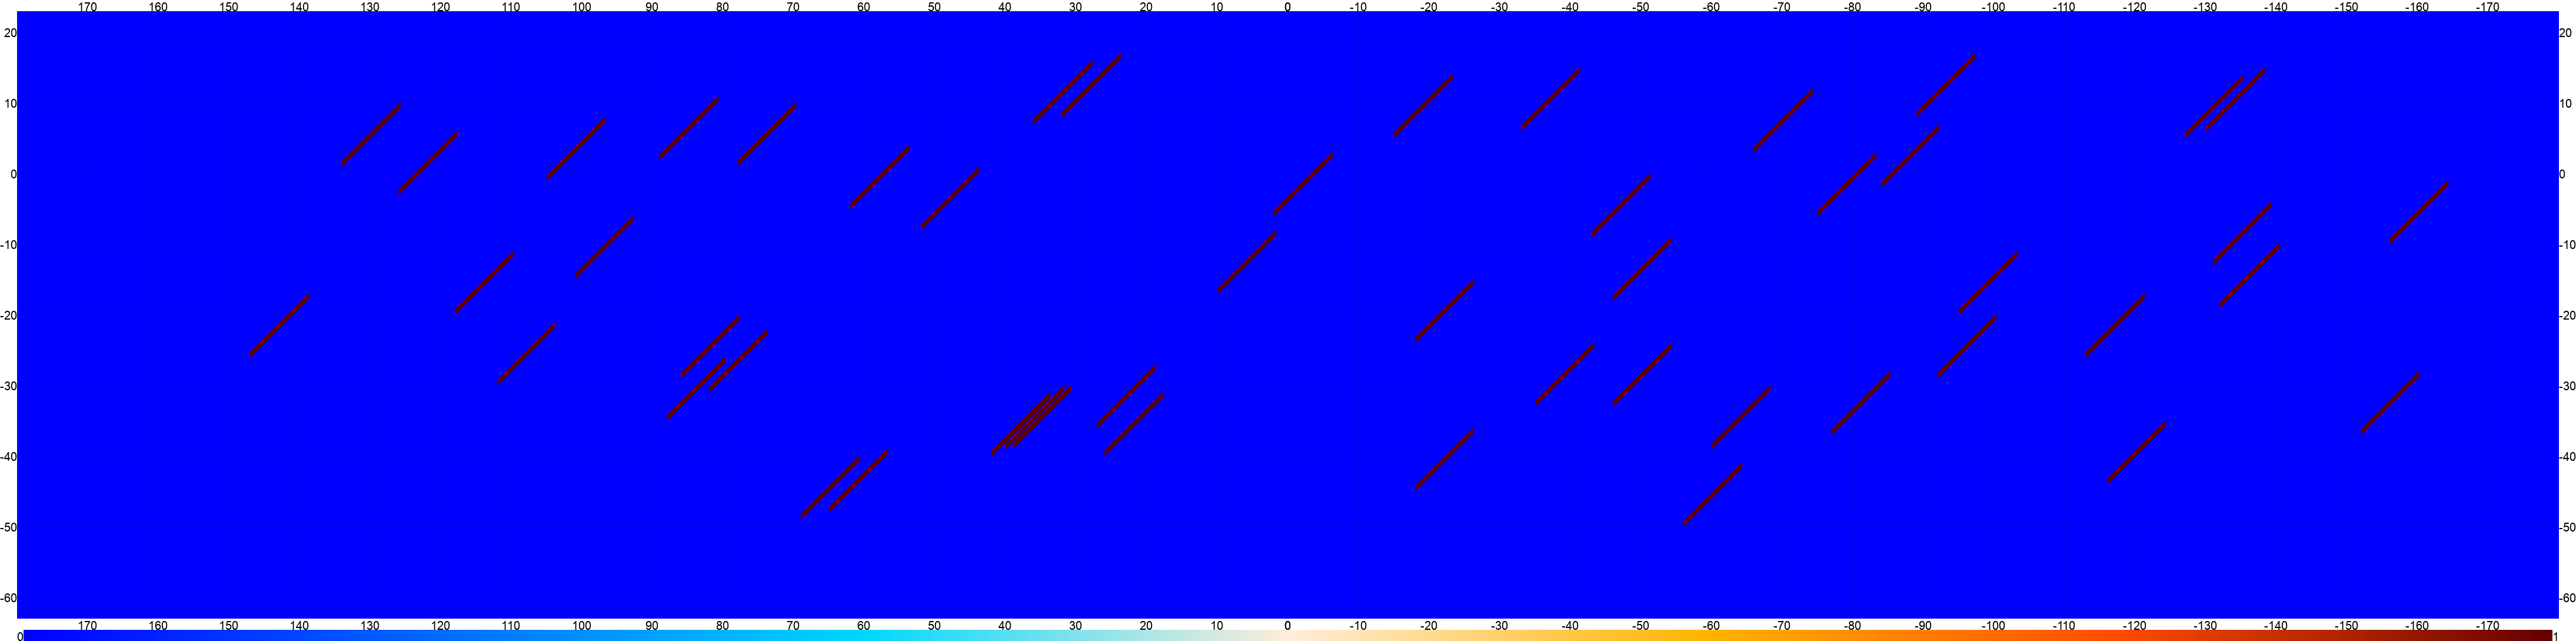

In [49]:
eshow(diaglines, colorbar=True, ticks=10)
# show the points


In [65]:
alpha, xpol, ypol, ca, sa, cut = sao.measure_orientation(ra, dec, diaglines_hpx_smth, dl_cotth, mode='density')

(50, 2, 2)
[-3.45532206e+17 -4.67200000e+03]
[-3.05068219e+17 -5.24800000e+03]
[-3.53094201e+17 -4.99200000e+03]
[-3.278465e+17 -4.480000e+03]
[-3.50905169e+17 -4.92800000e+03]
[-2.56504202e+17 -4.89600000e+03]
[-3.39321727e+17 -4.03200000e+03]
[-3.54920006e+17 -4.54400000e+03]
[-3.303618e+17 -4.288000e+03]
[-2.8999152e+17 -4.7360000e+03]
[-3.01495386e+17 -5.69600000e+03]
[-3.27174413e+17 -4.86400000e+03]
[-3.26870069e+17 -5.37600000e+03]
[-3.56295604e+17 -5.05600000e+03]
[-3.54134673e+17 -4.41600000e+03]
[-3.30357839e+17 -4.67200000e+03]
[-3.44081459e+17 -5.05600000e+03]
[-3.06949725e+17 -5.12000000e+03]
[-2.95154592e+17 -4.99200000e+03]
[-3.50351708e+17 -4.16000000e+03]
[-3.34450848e+17 -4.41600000e+03]
[-3.36613606e+17 -5.05600000e+03]
[-3.27334294e+17 -4.48000000e+03]
[-3.09871228e+17 -4.99200000e+03]
[-3.00174391e+17 -4.35200000e+03]
[-3.60366896e+17 -4.80000000e+03]
[-3.13702775e+17 -5.12000000e+03]
[-3.21150795e+17 -4.86400000e+03]
[-3.4265346e+17 -4.5440000e+03]
[-3.16065004e+1

In [66]:
Chunk = sf.Chunk(ra[cut], dec[cut], alpha, ypol, xpol)

In [67]:
stack = sf.stackChunk(Chunk, geom, diaglines, orient='random')

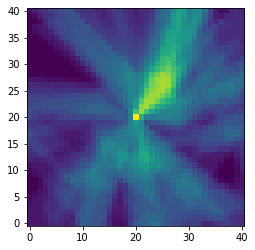

In [68]:
plt.imshow(stack, origin='lower')

In [73]:
stack = sf.stackChunk(Chunk, geom, diaglines, orient='original')

NameError: name 'diaglines_smth' is not defined

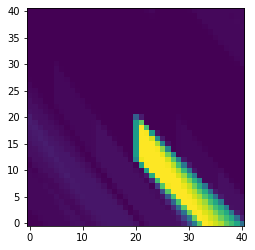

In [74]:
plt.imshow(stack, origin='lower')

In [71]:

stack = sf.stackChunk(Chunk, geom, diaglines, orient='sym', angledef='CCofRA')
# stack = sf.stackChunk(Chunk, geom, diaglines, orient='sym', angledef='CofDec')


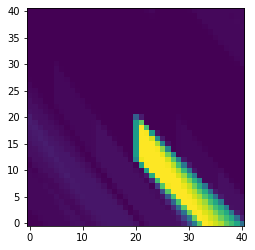

In [72]:
plt.imshow(stack, origin='lower')